In [ ]:
import numpy as np

def step(x):
  return 1 if x>=0 else 0

class Perceptron:
  def __init__(self,weights,bias):
    self.weights=weights
    self.bias=bias

  def predict(self,inputs):
    total=np.dot(self.weights,inputs)+self.bias
    return step(total)

weights=np.array([1,1])
bias=-1

andgate=Perceptron(weights,bias)
print("AND Gate: ")
for x in [(0,0), (0,1), (1,0), (1,1)]:
  print(x, "->", andgate.predict(np.array(x)))

AND Gate: 
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1


In [ ]:
weights = np.array([1, 1])
bias = -0.5
orgate = Perceptron(weights, bias)

print("\nOR Gate: ")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", orgate.predict(np.array(x)))


OR Gate: 
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1


In [ ]:
import numpy as np

class Perceptron:
  def __init__(self,lr=0.1,epochs=100):
    self.lr=lr
    self.epochs=epochs

  def step_function(self,x):
    return 1 if x>=0 else 0

  def fit(self,X,y):
    n_samples,n_features=X.shape
    self.weights=np.zeros(n_features)
    self.bias=0
    for _ in range(self.epochs):
      for i in range(n_samples):
        total=np.dot(self.weights,X[i])+self.bias
        y_pred=self.step_function(total)
        update=self.lr*(y[i]-y_pred)
        self.weights+=update*X[i]
        self.bias+=update

  def predict(self,inputs):
    linear_output=np.dot(self.weights,inputs)+self.bias
    print(self.weights)
    print(self.bias)
    return self.step_function(linear_output)

p=Perceptron()
X=np.array([[0,0],[0,1],[1,0],[1,1]])
y=np.array([0,1,1,0])
p.fit(X,y)

for i in X:
  print(p.predict(i))

[-0.1  0. ]
0.0
1
[-0.1  0. ]
0.0
1
[-0.1  0. ]
0.0
0
[-0.1  0. ]
0.0
0


In [ ]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([[0], [1], [1], [0]])

np.random.seed(0)
W1 = np.random.randn(2, 2)
b1 = np.zeros((1, 2))
W2 = np.random.randn(2, 1)
b2 = np.zeros((1, 1))

lr = 0.1
epochs = 10000

for _ in range(epochs):
    h = sigmoid(np.dot(X, W1) + b1)
    out = sigmoid(np.dot(h, W2) + b2)

    error = y - out
    d_out = error * sigmoid_derivative(out)
    d_h = d_out.dot(W2.T) * sigmoid_derivative(h)

    W2 += h.T.dot(d_out) * lr
    b2 += np.sum(d_out, axis=0, keepdims=True) * lr
    W1 += X.T.dot(d_h) * lr
    b1 += np.sum(d_h, axis=0, keepdims=True) * lr

xor_output = np.round(out)
xnor_output = 1 - xor_output

print("XOR Output:")
print(xor_output)
print("\nXNOR Output:")
print(xnor_output)

XOR Output:
[[0.]
 [0.]
 [1.]
 [1.]]

XNOR Output:
[[1.]
 [1.]
 [0.]
 [0.]]


In [ ]:
import numpy as np

def perceptron(x, w, b):
    z = np.dot(x, w) + b
    return 1 if z >= 0 else 0
w = np.array([1, 1])
b = -1
inputs = [
    [0.50, 0.49],
    [0.50, 0.50],
    [0.50, 0.51]
]
for x in inputs:
    print(x, "->", perceptron(x, w, b))

[0.5, 0.49] -> 0
[0.5, 0.5] -> 1
[0.5, 0.51] -> 1


In [ ]:
import numpy as np
import pandas as pd

data = pd.read_csv("/content/filmdata.csv")

X = data[["MattDamon", "Thriller", "Nolan", "IMDB"]].values
y = data["Like"].values

y = np.where(y == 0, -1, 1)
X = np.c_[np.ones(X.shape[0]), X]

np.random.seed(1)
weights = np.random.randn(X.shape[1])
learning_rate = 0.1
epochs = 20

for epoch in range(epochs):
    errors = 0
    for i in range(len(X)):
        prediction = np.sign(np.dot(X[i], weights))
        if prediction == 0:
            prediction = -1

        if prediction != y[i]:
            weights += learning_rate * y[i] * X[i]
            errors += 1

    print(f"Epoch {epoch + 1}: Misclassifications = {errors}")
    print("Weights:", weights)

print("\nFinal Weights:", weights)


Epoch 1: Misclassifications = 3
Weights: [ 1.32434536 -0.71175641 -0.62817175 -1.17296862  0.74540763]
Epoch 2: Misclassifications = 2
Weights: [ 1.12434536 -0.71175641 -0.72817175 -1.17296862  0.67540763]
Epoch 3: Misclassifications = 3
Weights: [ 1.02434536 -0.71175641 -0.72817175 -1.07296862  0.69540763]
Epoch 4: Misclassifications = 3
Weights: [ 0.92434536 -0.71175641 -0.72817175 -0.97296862  0.71540763]
Epoch 5: Misclassifications = 3
Weights: [ 0.82434536 -0.71175641 -0.72817175 -0.87296862  0.73540763]
Epoch 6: Misclassifications = 3
Weights: [ 0.72434536 -0.71175641 -0.72817175 -0.77296862  0.75540763]
Epoch 7: Misclassifications = 3
Weights: [ 0.62434536 -0.61175641 -0.72817175 -0.77296862  0.77040763]
Epoch 8: Misclassifications = 3
Weights: [ 0.52434536 -0.51175641 -0.72817175 -0.77296862  0.78540763]
Epoch 9: Misclassifications = 3
Weights: [ 0.42434536 -0.41175641 -0.72817175 -0.77296862  0.80040763]
Epoch 10: Misclassifications = 4
Weights: [ 0.42434536 -0.31175641 -0.628

WEEK-1

In [ ]:
#1Q
import torch
import torch.nn as nn

class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.layer1 = nn.Linear(3, 5)
        self.layer2 = nn.Linear(5, 1)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)
        return x

model = SimpleNet()
print("Model Architecture:")
print(model)

input_data = torch.randn(1, 3)
output = model(input_data)

print("\nInput:", input_data)
print("Output:", output)

Model Architecture:
SimpleNet(
  (layer1): Linear(in_features=3, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
  (activation): ReLU()
)

Input: tensor([[-0.3583, -0.4466, -0.1831]])
Output: tensor([[0.1132]], grad_fn=<AddmmBackward0>)


In [ ]:
#2Q
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

model = Sequential()
model.add(Dense(units=5, input_shape=(3,), activation='relu'))
model.add(Dense(units=1))
model.compile(optimizer='sgd', loss='mean_squared_error')

print("Model Summary:")
model.summary()
dummy_input = np.random.rand(1, 3)
prediction = model.predict(dummy_input)

print("\nInput:", dummy_input)
print("Prediction:", prediction)

Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26 (104.00 B)

 Trainable params: 26 (104.00 B)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step

Input: [[0.27811259 0.98183987 0.85791234]]
Prediction: [[-0.13591725]]


In [1]:
import tensorflow as tf
import numpy as np

x = np.array([1, 2, 3, 4], dtype=float)
y = np.array([2, 4, 6, 8], dtype=float)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='sgd', loss='mse')

model.fit(x, y, epochs=500, verbose=0)

test = np.array([5.0])
prediction = model.predict(test, verbose=0)

print("Prediction:", prediction[0][0])
print("Fianl Loss",model.evaluate(x,y))

Prediction: 9.857857
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.0069
Fianl Loss 0.0068745785392820835


In [ ]:
#Q3
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(5, activation='relu', input_shape=(1,)))
model.add(Dense(1))
model.compile(
    optimizer='sgd',
    loss='mean_squared_error'
)

x = np.array([1, 2, 3, 4], dtype=float)
y = np.array([2, 4, 6, 8], dtype=float)

model.fit(x, y, epochs=1000, verbose=0)
print(model.predict(np.array([[5]])))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
[[9.999937]]


In [ ]:
#4Q
import math

def step(z):
    if z >= 0:
        return 1
    else:
        return 0

def sigmoid(z):
    return 1 / (1 + math.exp(-z))

def perceptron(x1, x2, w1, w2, b):
    z = (w1 * x1) + (w2 * x2) + b
    return step(z), sigmoid(z)

step_out, sig_out = perceptron(1, 1, 0.5, 0.5, -0.5)
print("Step Output:", step_out)
print("Sigmoid Output:", sig_out)

Step Output: 1
Sigmoid Output: 0.6224593312018546


In [2]:
import math

def step_function(x):
    return 1 if x >= 0 else 0

def perceptron(inputs, weights, bias):
    weighted_sum = 0
    for i in range(len(inputs)):
        weighted_sum += inputs[i] * weights[i]

    weighted_sum += bias
    output = step_function(weighted_sum)
    return output

inputs = [1, 0]
weights = [0.7, -0.4]
bias = -0.2

print("Perceptron Output:", perceptron(inputs, weights, bias))

Perceptron Output: 1


WEEK-2

In [ ]:
#1Q
def step(z):
    return 1 if z >= 0 else 0

def perceptron(x1, x2, w1, w2, b):
    z = w1*x1 + w2*x2 + b
    return step(z)

print("AND Gate")
for x1, x2 in [(0,0),(0,1),(1,0),(1,1)]:
    print(x1, x2, perceptron(x1, x2, 1, 1, -1.5))

print("\nOR Gate")
for x1, x2 in [(0,0),(0,1),(1,0),(1,1)]:
    print(x1, x2, perceptron(x1, x2, 1, 1, -0.5))


AND Gate
0 0 0
0 1 0
1 0 0
1 1 1

OR Gate
0 0 0
0 1 1
1 0 1
1 1 1


In [ ]:
#2Q
def step(z):
    return 1 if z >= 0 else 0

def perceptron(x1, x2, w1, w2, b):
    z = w1*x1 + w2*x2 + b
    return step(z)

print("XOR using Single Perceptron")
print("x1 x2 output")

for x1, x2 in [(0,0), (0,1), (1,0), (1,1)]:
    y = perceptron(x1, x2, 1, 1, -1)
    print(x1, x2, y)

XOR using Single Perceptron
x1 x2 output
0 0 0
0 1 1
1 0 1
1 1 1


In [ ]:
print("\nXNOR using Single Perceptron")
print("x1 x2 output")

for x1, x2 in [(0,0), (0,1), (1,0), (1,1)]:
    y = perceptron(x1, x2, -1, -1, 1)
    print(x1, x2, y)



XNOR using Single Perceptron
x1 x2 output
0 0 1
0 1 1
1 0 1
1 1 0


XOR and XNOR cannot be implemented using a single perceptron because they are not linearly separable.
A single perceptron can only learn decision boundaries that are linear (straight lines), whereas XOR/XNOR require a non-linear decision boundary.

In [ ]:
#3Q
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([[0],[1],[1],[0]])

model_xor = Sequential()
model_xor.add(Dense(4, activation='relu', input_shape=(2,)))
model_xor.add(Dense(1, activation='sigmoid'))
model_xor.compile(optimizer='adam', loss='binary_crossentropy')
model_xor.fit(X, y_xor, epochs=1000, verbose=0)

print("XOR Output:")
print(model_xor.predict(X))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


XOR Output:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
[[0.48511833]
 [0.5116978 ]
 [0.4870854 ]
 [0.51366514]]


In [ ]:
y_xnor = np.array([[1],[0],[0],[1]])

model_xnor = Sequential()
model_xnor.add(Dense(4, activation='relu', input_shape=(2,)))
model_xnor.add(Dense(1, activation='sigmoid'))
model_xnor.compile(optimizer='adam', loss='binary_crossentropy')
model_xnor.fit(X, y_xnor, epochs=1000, verbose=0)

print("XNOR Output:")
print(model_xnor.predict(X))

XNOR Output:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
[[0.45985538]
 [0.45985538]
 [0.46017927]
 [0.6527435 ]]


In [3]:
# XOR and XNOR using Multi Layer Perceptron

def step(x):
    return 1 if x>=0 else 0

def perceptron(x1,x2,w1,w2,b):
    return step(x1*w1 + x2*w2 + b)

inputs = [(0,0),(0,1),(1,0),(1,1)]

print("XOR & XNOR using multi perceptron")

for x1,x2 in inputs:

    h2 = perceptron(x1,x2,1,1,-1.5)     # AND
    h1 = perceptron(x1,x2,1,1,-0.5)     # OR

    y = perceptron(h1,h2,1, -2, -0.5)
    not_xor = perceptron(y, 0, -1, 0, 0.5)


    print(x1,x2,"->",y, not_xor)

XOR & XNOR using multi perceptron
0 0 -> 0 1
0 1 -> 1 0
1 0 -> 1 0
1 1 -> 0 1


In [9]:
#4Q
import math

def step(x):
    return 1 if x >= 0 else 0

def sigmoid(x):
    return 1 / (1 + math.exp(-x))
values = [-0.1, -0.01, 0, 0.01, 0.1]

print("x\tStep\tSigmoid")
for v in values:
    print(v, "\t", step(v), "\t", round(sigmoid(v), 3))

x	Step	Sigmoid
-0.1 	 0 	 0.475
-0.01 	 0 	 0.498
0 	 1 	 0.5
0.01 	 1 	 0.502
0.1 	 1 	 0.525


Threshold logic is harsh because a very small change in input causes a sudden change in output.
This makes learning difficult.
Sigmoid activation provides smooth output and is better suited for learning in neural networks.

In [ ]:
#5Q
import pandas as pd
import numpy as np

def step(z):
    return 1 if z >= 0 else 0

data = pd.read_csv("/content/moviedata.csv")

X = data[['x1', 'x2']].values
y = data['label'].values

X = np.insert(X, 0, 1, axis=1)

w = np.zeros(X.shape[1])

for epoch in range(10):
    for i in range(len(X)):
        z = np.dot(w, X[i])
        y_pred = step(z)
        if y_pred != y[i]:
            if y[i] == 1:
                w = w + X[i]
            else:
                w = w - X[i]

print("Final Weights:", w)

Final Weights: [-3.  2.  1.]


In [10]:
import numpy as np

X = np.array([
    [1,1,1,0.9],
    [1,0,0,0.7],
    [0,1,0,0.6],
    [0,0,1,0.4],
    [1,1,0,0.8],
    [0,0,0,0.3]
])

y = np.array([1,1,0,0,1,0])

w = np.zeros(4)
b = 0
lr = 0.1

for epoch in range(10):
    for i in range(len(X)):
        z = np.dot(X[i], w) + b
        pred = 1 if z >= 0 else 0
        err = y[i] - pred

        w += lr * err * X[i]
        b += lr * err

print("Weights:", w)
print("Bias:", b)

test = np.array([1,1,0,0.85])

z = np.dot(test, w) + b
print("LIKE" if z >= 0 else "DISLIKE")

Weights: [3.00000000e-01 0.00000000e+00 0.00000000e+00 4.16333634e-17]
Bias: -0.2
LIKE


In [11]:
#6Q
#representation power of neurons
import numpy as np
import itertools

# input dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])

def train_perceptron(y):

    w = np.zeros(2)
    b = 0
    lr = 0.1

    for epoch in range(20):
        error_count = 0

        for i in range(len(X)):
            z = np.dot(X[i],w) + b
            y_pred = 1 if z>=0 else 0

            error = y[i] - y_pred

            if error != 0:
                error_count += 1

            w = w + lr * error * X[i]
            b = b + lr * error

        if error_count == 0:
            return True

    return False


# generate all 16 boolean functions
functions = list(itertools.product([0,1], repeat=4))

learnable = 0
not_learnable = 0

for f in functions:
    y = np.array(f)

    if train_perceptron(y):
        learnable += 1
    else:
        not_learnable += 1

print("Learnable functions:",learnable)
print("Not learnable functions:",not_learnable)

Learnable functions: 14
Not learnable functions: 2


In [ ]:
#7Q
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

# Hidden layer: fires for exactly one input
def hidden_layer(x1, x2):
    return [
        step(-2 + (-1)*x1 + (-1)*x2),  # h1 → (0,0)
        step(-2 + (-1)*x1 + (1)*x2),   # h2 → (0,1)
        step(-2 + (1)*x1 + (-1)*x2),   # h3 → (1,0)
        step(-2 + (1)*x1 + (1)*x2)     # h4 → (1,1)
    ]

# Output neuron
def mlp(x1, x2, weights):
    h = hidden_layer(x1, x2)
    y = sum(w*h_i for w, h_i in zip(weights, h))
    return step(y)

# Example: XOR → output = 1 for (0,1) and (1,0)
xor_weights = [0, 1, 1, 0]

print("XOR using MLP:")
for x1, x2 in [(0,0),(0,1),(1,0),(1,1)]:
    print(x1, x2, "->", mlp(x1, x2, xor_weights))


XOR using MLP:
0 0 -> 1
0 1 -> 1
1 0 -> 1
1 1 -> 1


In [12]:
#7Q
#multi-layer perceptron architecture
import numpy as np

def step(x):
    return 1 if x >= 0 else 0


# hidden perceptrons
def h1(x1,x2):
    return step(-x1 -x2 + 0.5)   # detects (0,0)

def h2(x1,x2):
    return step(-x1 +x2 -0.5)    # detects (0,1)

def h3(x1,x2):
    return step(x1 -x2 -0.5)     # detects (1,0)

def h4(x1,x2):
    return step(x1 +x2 -1.5)     # detects (1,1)


# MLP output neuron
def mlp(x1,x2,w):

    H1 = h1(x1,x2)
    H2 = h2(x1,x2)
    H3 = h3(x1,x2)
    H4 = h4(x1,x2)

    z = w[0]*H1 + w[1]*H2 + w[2]*H3 + w[3]*H4 - 0.5

    return step(z)


# Example Boolean Function: XOR
weights = [0,1,1,0]

inputs = [(0,0),(0,1),(1,0),(1,1)]

print("XOR Output")

for x1,x2 in inputs:
    print(x1,x2,"->",mlp(x1,x2,weights))

XOR Output
0 0 -> 0
0 1 -> 1
1 0 -> 1
1 1 -> 0


In [ ]:
#8Q
import itertools

def step(x):
    return 1 if x >= 0 else 0

def hidden_layer(x):
    h = []
    for pattern in itertools.product([0,1], repeat=3):
        s = sum((1 if p==1 else -1)*xi for p, xi in zip(pattern, x)) - 3
        h.append(step(s))
    return h

def mlp(x, weights):
    h = hidden_layer(x)
    return step(sum(w*h_i for w, h_i in zip(weights, h)))

# Example: odd parity (3-input XOR)
weights = [0,1,1,0,1,0,0,1]

for x in itertools.product([0,1], repeat=3):
    print(x, "->", mlp(x, weights))


(0, 0, 0) -> 1
(0, 0, 1) -> 1
(0, 1, 0) -> 1
(0, 1, 1) -> 1
(1, 0, 0) -> 1
(1, 0, 1) -> 1
(1, 1, 0) -> 1
(1, 1, 1) -> 1


In [ ]:
#8Q
#three binary inputs
import numpy as np

def step(x):
    return 1 if x >= 0 else 0


def hidden_layer(x1,x2,x3):

    h1 = step(-x1 -x2 -x3 +0.5)
    h2 = step(-x1 -x2 +x3 -0.5)
    h3 = step(-x1 +x2 -x3 -0.5)
    h4 = step(-x1 +x2 +x3 -1.5)
    h5 = step(x1 -x2 -x3 -0.5)
    h6 = step(x1 -x2 +x3 -1.5)
    h7 = step(x1 +x2 -x3 -1.5)
    h8 = step(x1 +x2 +x3 -2.5)

    return [h1,h2,h3,h4,h5,h6,h7,h8]


def mlp(x1,x2,x3,weights):

    h = hidden_layer(x1,x2,x3)

    z = sum(w*h_i for w,h_i in zip(weights,h)) - 0.5

    return step(z)


inputs = [
(0,0,0),
(0,0,1),
(0,1,0),
(0,1,1),
(1,0,0),
(1,0,1),
(1,1,0),
(1,1,1)
]

# example boolean function weights
weights = [0,1,0,1,1,0,1,0]

for x1,x2,x3 in inputs:
    print(x1,x2,x3,"->",mlp(x1,x2,x3,weights))

WEEK-3

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


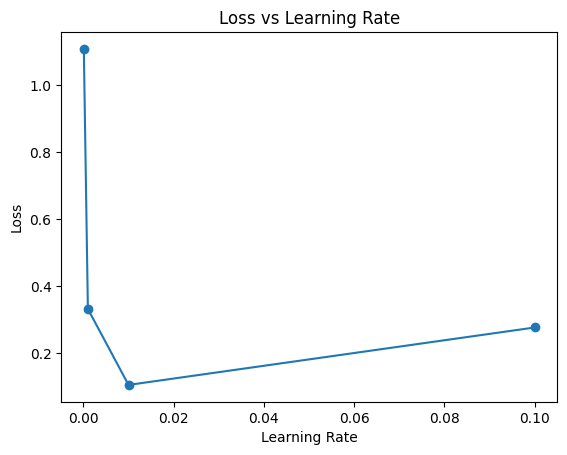

In [ ]:
#9Q
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss
from sklearn.preprocessing import StandardScaler

data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

learning_rates = [0.0001, 0.001, 0.01, 0.1]
loss_values = []

for lr in learning_rates:
    model = MLPClassifier(hidden_layer_sizes=(10,),
                          learning_rate_init=lr,
                          max_iter=300,
                          random_state=1)

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)
    loss = log_loss(y_test, y_prob)
    loss_values.append(loss)

plt.plot(learning_rates, loss_values, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Loss vs Learning Rate")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Learning Rate: 0.0001, Loss: 1.095392


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Learning Rate: 0.001, Loss: 0.146223
Learning Rate: 0.01, Loss: 0.019823
Learning Rate: 0.1, Loss: 0.014309


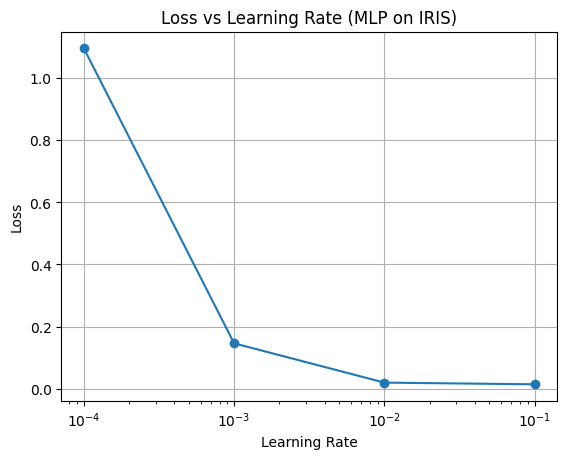

In [ ]:
# Week-3 Q9
# MLP – Effect of Learning Rate on Loss

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss
from sklearn.preprocessing import StandardScaler

data = load_iris()
X = data.data
y = data.target

# Fixed random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


learning_rates = [0.0001, 0.001, 0.01, 0.1]
loss_values = []

for lr in learning_rates:

    model = MLPClassifier(
        hidden_layer_sizes=(10,),
        learning_rate_init=lr,
        max_iter=500,
        random_state=42
    )

    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_test)

    # Compute loss
    loss = log_loss(y_test, y_prob)
    loss_values.append(loss)

    print(f"Learning Rate: {lr}, Loss: {loss:.6f}")


plt.figure()
plt.plot(learning_rates, loss_values, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Loss vs Learning Rate (MLP on IRIS)")
plt.xscale("log")     # important improvement
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


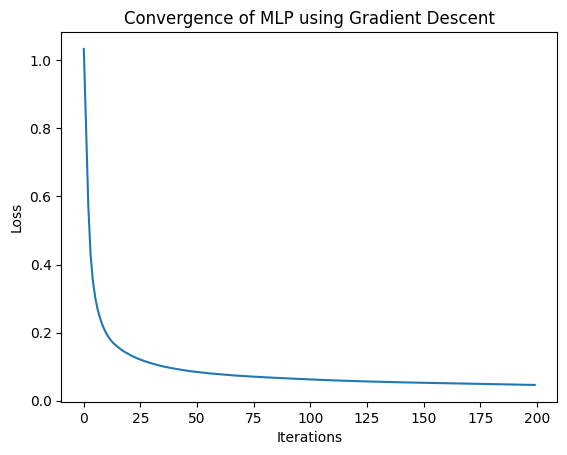

Training Accuracy: 0.989010989010989
Testing Accuracy: 0.9824561403508771


In [ ]:
#10Q
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(10,),
    solver='sgd',
    learning_rate_init=0.01,
    max_iter=200,
    random_state=1)

mlp.fit(X_train, y_train)

plt.plot(mlp.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Convergence of MLP using Gradient Descent")
plt.show()

print("Training Accuracy:", mlp.score(X_train, y_train))
print("Testing Accuracy:", mlp.score(X_test, y_test))

Epoch     0 | Loss: 0.250132
Epoch  1000 | Loss: 0.250001
Epoch  2000 | Loss: 0.250000
Epoch  3000 | Loss: 0.250000
Epoch  4000 | Loss: 0.250000
Epoch  5000 | Loss: 0.250000
Epoch  6000 | Loss: 0.250000
Epoch  7000 | Loss: 0.250000
Epoch  8000 | Loss: 0.250000
Epoch  9000 | Loss: 0.250000

Final Predictions:
[[0.]
 [1.]
 [0.]
 [1.]]

Actual:
[[0.]
 [1.]
 [1.]
 [0.]]


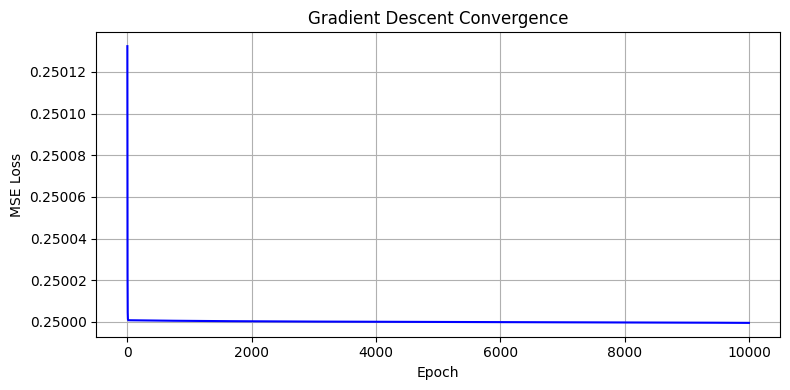

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Dataset: XOR ──────────────────────────────────────────
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y = np.array([[0],[1],[1],[0]],         dtype=np.float32)

# ── Activation Functions ───────────────────────────────────
def sigmoid(x):
    return 1 / (1 + np.exp(-x))        # Output always between 0 and 1

def sigmoid_derivative(x):
    return x * (1 - x)                 # Derivative of sigmoid (x is already sigmoid output)

# ── Initialize Weights ─────────────────────────────────────
np.random.seed(42)                      # Fixed seed for reproducibility

# Architecture: 2 inputs → 4 hidden → 1 output
W1 = np.random.randn(2, 4) * 0.1       # Shape (2,4): 2 input neurons, 4 hidden neurons
b1 = np.zeros((1, 4))                   # Bias for hidden layer

W2 = np.random.randn(4, 1) * 0.1       # Shape (4,1): 4 hidden neurons, 1 output neuron
b2 = np.zeros((1, 1))                   # Bias for output layer

lr = 0.5                                # Learning rate
epochs = 10000                          # Number of training iterations
losses = []                             # Store loss at each epoch

# ── Training Loop (Batch Gradient Descent) ─────────────────
for epoch in range(epochs):

    # ── FORWARD PASS ──────────────────────────────────────
    z1 = X @ W1 + b1                    # Weighted sum for hidden layer: shape (4,4)
    h  = sigmoid(z1)                    # Apply sigmoid to hidden layer output

    z2 = h @ W2 + b2                    # Weighted sum for output layer: shape (4,1)
    o  = sigmoid(z2)                    # Final output (predictions)

    # ── LOSS ──────────────────────────────────────────────
    loss = np.mean((y - o) ** 2)        # Mean Squared Error (MSE)
    losses.append(loss)

    # ── BACKWARD PASS ─────────────────────────────────────
    # Output layer gradients
    d_loss_o  = (o - y)                             # dLoss/dOutput = (predicted - true)
    d_o_z2    = sigmoid_derivative(o)               # dOutput/dZ2
    delta_o   = d_loss_o * d_o_z2                   # Delta at output: shape (4,1)

    # Hidden layer gradients (chain rule: propagate delta back through W2)
    d_z2_h    = W2.T                                # dZ2/dHidden = W2 transposed
    d_loss_h  = delta_o @ d_z2_h                    # dLoss/dHidden: shape (4,4)
    d_h_z1    = sigmoid_derivative(h)               # dHidden/dZ1
    delta_h   = d_loss_h * d_h_z1                   # Delta at hidden: shape (4,4)

    # ── GRADIENTS ─────────────────────────────────────────
    dW2 = h.T @ delta_o                 # Gradient for W2: shape (4,1)
    db2 = delta_o.sum(axis=0)           # Gradient for b2: shape (1,1)

    dW1 = X.T @ delta_h                 # Gradient for W1: shape (2,4)
    db1 = delta_h.sum(axis=0)           # Gradient for b1: shape (1,4)

    # ── WEIGHT UPDATE (Gradient Descent) ──────────────────
    W2 -= lr * dW2                      # Move W2 in direction that reduces loss
    b2 -= lr * db2
    W1 -= lr * dW1                      # Move W1 in direction that reduces loss
    b1 -= lr * db1

    # Print loss every 1000 epochs
    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss:.6f}")

# ── Results ────────────────────────────────────────────────
print("\nFinal Predictions:")
print(np.round(o))                       # Should be [[0],[1],[1],[0]] for XOR

print("\nActual:")
print(y)

# ── Plot Loss Curve ────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(losses, color='blue')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent Convergence")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#10 Implement an MLP using the Gradient Descent algorithm, and analyze the convergence behavior and performance of the network.
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Initializing weights and bias
np.random.seed(0)
W1 = np.random.rand(2,2)
b1 = np.random.rand(1,2)
W2 = np.random.rand(2,1)
b2 = np.random.rand(1,1)

lr = 0.5
epochs = 20000
losses = []

# Gradient Descent Training
for _ in range(epochs):
    # Forward pass
    h = sigmoid(np.dot(X, W1) + b1)
    y_pred = sigmoid(np.dot(h, W2) + b2)

    # Loss (MSE)
    loss = np.mean((y - y_pred)**2)
    losses.append(loss)

    # Backpropagation
    d_out = (y - y_pred) * sigmoid_derivative(y_pred)
    d_h = np.dot(d_out, W2.T) * sigmoid_derivative(h)

    # Gradient descent updates
    W2 += lr * np.dot(h.T, d_out)
    b2 += lr * np.sum(d_out, axis=0)
    W1 += lr * np.dot(X.T, d_h)
    b1 += lr * np.sum(d_h, axis=0)

print(f"Learnig rate: {lr}, Loss: {loss:.7f}")
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MLP Convergence using Gradient Descent")
plt.show()

print("Final Predictions:")
for i in range(len(X)):
    pred = int(y_pred[i][0] >= 0.5)
    print(X[i], "→", pred)

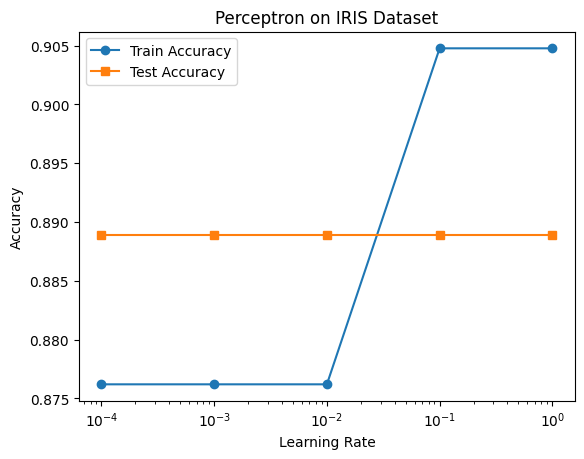

In [ ]:
#11Q
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0]
train_acc = []
test_acc = []

for lr in learning_rates:
    model = Perceptron(
        eta0=lr,
        max_iter=1000,
        random_state=42)

    model.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(learning_rates, train_acc, marker='o', label="Train Accuracy")
plt.plot(learning_rates, test_acc, marker='s', label="Test Accuracy")
plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Perceptron on IRIS Dataset")
plt.legend()
plt.show()

Learning Rate Analysis:

LR=0.0001 | Train Acc=0.8762 | Test Acc=0.8889
LR=0.001  | Train Acc=0.8762 | Test Acc=0.8889
LR=0.01   | Train Acc=0.8762 | Test Acc=0.8889
LR=0.1    | Train Acc=0.9048 | Test Acc=0.8889
LR=1.0    | Train Acc=0.9048 | Test Acc=0.8889


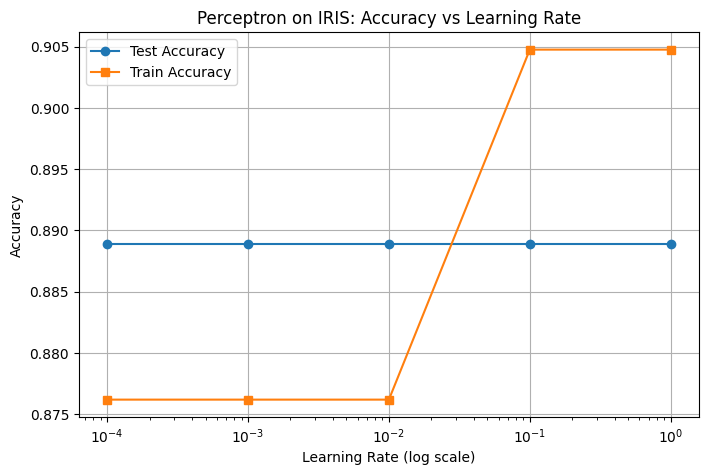

In [ ]:
# Load IRIS dataset
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron # Added import for Perceptron
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score # Added import for accuracy_score

data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0]

train_accuracies = []
test_accuracies = []

print("Learning Rate Analysis:\n")

for lr in learning_rates:
    perceptron = Perceptron(
        eta0=lr,
        max_iter=1000,
        tol=1e-3,
        fit_intercept=True,
        shuffle=True,
        random_state=42
    )

    perceptron.fit(X_train, y_train)

    # Predictions
    y_train_pred = perceptron.predict(X_train)
    y_test_pred = perceptron.predict(X_test)

    # Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"LR={lr:<6} | Train Acc={train_acc:.4f} | Test Acc={test_acc:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(learning_rates, test_accuracies, marker='o', label="Test Accuracy")
plt.plot(learning_rates, train_accuracies, marker='s', label="Train Accuracy")
plt.xscale("log")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Accuracy")
plt.title("Perceptron on IRIS: Accuracy vs Learning Rate")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#12Q
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

df = pd.read_csv("/content/breast_cancer.csv")
X = df.drop(columns=['id', 'diagnosis']).values
y = df['diagnosis'].map({'M': 1, 'B': 0}).values

if np.isnan(X).any():
    imputer = SimpleImputer(strategy='mean')
    X = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

configs = [
    (0.001, 200),
    (0.01, 200),
    (0.01, 500),
    (0.1, 200)
]

for lr, iters in configs:
    model = MLPClassifier(
        hidden_layer_sizes=(20,),
        learning_rate_init=lr,
        max_iter=iters,
        random_state=1
    )

    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)

    print(f"LR={lr}, Iterations={iters}, Test Accuracy={acc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [30]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


LR=0.001, Iterations=200, Test Accuracy=0.9737
LR=0.01, Iterations=200, Test Accuracy=0.9737
LR=0.01, Iterations=500, Test Accuracy=0.9737
LR=0.1, Iterations=200, Test Accuracy=0.9825


In [ ]:
#13Q
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=300,
    learning_rate_init=0.01,
    random_state=1)

mlp.fit(X_train, y_train)

print("Training Accuracy:", mlp.score(X_train, y_train))
print("Testing Accuracy:", mlp.score(X_test, y_test))


Training Accuracy: 1.0
Testing Accuracy: 0.9722222222222222


In [ ]:
import numpy as np
import sklearn.datasets as skl_data
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

# --- 1. Load MNIST dataset ---
data, labels = skl_data.fetch_openml('mnist_784', version=1, return_X_y=True)

# Convert labels from string to integer
labels = labels.astype(int)

# Normalize pixel values to [0,1]
data = data / 255.0

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

# --- 2. Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.10, random_state=42, stratify=labels
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# --- 3. Create MLP classifier ---
# Single hidden layer with 175 neurons
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=200,
    verbose=1,
    random_state=1
)

# --- 4. Train MLP ---
mlp.fit(X_train, y_train)

# --- 5. Evaluate ---

print("Training set accuracy:", mlp.score(X_train, y_train))
print("Testing set accuracy:", mlp.score(X_test, y_test))

# --- 6. Predict a single digit ---
index = 346
test_digit = X_test.iloc[index].to_numpy().reshape(1, 784)  # use .iloc for row
test_digit_prediction = mlp.predict(test_digit)[0]

print("Predicted value:", test_digit_prediction)
print("Actual value:", y_test.iloc[index])

Data shape: (70000, 784)
Labels shape: (70000,)
X_train shape: (63000, 784)
X_test shape: (7000, 784)
Iteration 1, loss = 0.42565461
Iteration 2, loss = 0.19726882
Iteration 3, loss = 0.14291616
Iteration 4, loss = 0.11261497
Iteration 5, loss = 0.09346874
Iteration 6, loss = 0.07826463
Iteration 7, loss = 0.06785235
Iteration 8, loss = 0.05861600
Iteration 9, loss = 0.05145396
Iteration 10, loss = 0.04482108
Iteration 11, loss = 0.04062207
Iteration 12, loss = 0.03541223
Iteration 13, loss = 0.03153407
Iteration 14, loss = 0.02776332
Iteration 15, loss = 0.02485132
Iteration 16, loss = 0.02206290
Iteration 17, loss = 0.01975107
Iteration 18, loss = 0.01745703
Iteration 19, loss = 0.01587820
Iteration 20, loss = 0.01402050
Iteration 21, loss = 0.01217523
Iteration 22, loss = 0.01129783
Iteration 23, loss = 0.00983355
Iteration 24, loss = 0.00916938
Iteration 25, loss = 0.00783648
Iteration 26, loss = 0.00703042
Iteration 27, loss = 0.00686925
Iteration 28, loss = 0.00592041
Iteration 2

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
